In [59]:
import pandas as pd
df=pd.read_csv('/content/Enhanced_Resume_Dataset_10504_Mixed_Filled.csv')
df.head(2)


,Candidate_ID,Name,Age,Gender,City,Degree,Experience_Years,Skills,Projects_Count,Certifications,Resume_Summary,Target_Designation
0,C05465,Candidate_5465,24,Male,Mumbai,B.Tech,11,"SQL, Pandas, Python, Git, MLflow, CV, PyTorch,...",7,TensorFlow,ML Engineer with 11 years of experience.,ML Engineer
1,C10022,Candidate_10022,32,Male,Kochi,M.Tech,7,"Canva, Meta Ads, Analytics, Keyword Research, ...",9,Azure AZ-900,Digital Marketing with 7 years of experience.,Digital Marketing


In [60]:
# df.dropna(inplace=True)

In [61]:
df.drop(['Candidate_ID','Name','Age','Gender','City','Degree','Experience_Years','Projects_Count','Certifications','Resume_Summary'],axis=1,inplace=True)
df.tail()

,Skills,Target_Designation
10499,"Recruitment, ATS, HRMS, Conflict Resolution, E...",HR Manager
10500,"MongoDB, Python, JWT, Linux, Docker, Flask, Fa...",Backend Developer
10501,"CI/CD, Jenkins, Kubernetes, AWS, Docker, Pytho...",Cloud Engineer
10502,"HTML, TypeScript, Bootstrap, REST, Tailwind, C...",Front End Developer
10503,"Typography, UI, Wireframing, After Effects, Ca...",Designer


In [62]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10504 entries, 0 to 10503
Data columns (total 2 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Skills              10504 non-null  object
 1   Target_Designation  10504 non-null  object
dtypes: object(2)
memory usage: 164.3+ KB


In [63]:
print(df.isna().sum())      # NaN count per column
print(df.isna().sum().sum())

Skills                0
Target_Designation    0
dtype: int64
0


In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10504 entries, 0 to 10503
Data columns (total 2 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Skills              10504 non-null  object
 1   Target_Designation  10504 non-null  object
dtypes: object(2)
memory usage: 164.3+ KB


In [65]:
df['Target_Designation'].value_counts()

,count
Target_Designation,
ML Engineer,1313
Digital Marketing,1313
Cloud Engineer,1313
Backend Developer,1313
Designer,1313
Front End Developer,1313
HR Manager,1313
Data Analyst,1313


<Axes: xlabel='Target_Designation', ylabel='count'>

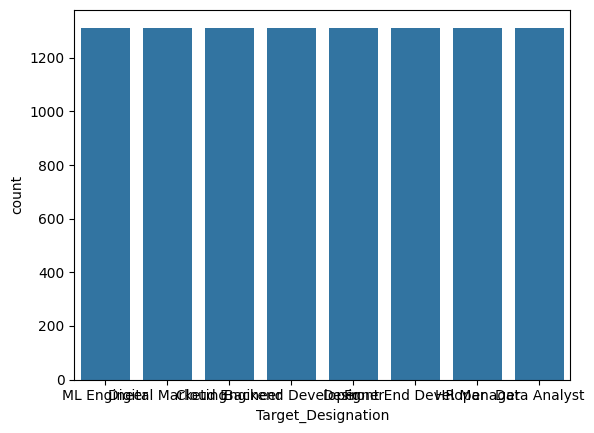

In [66]:
import seaborn as sns
sns.countplot(x=df['Target_Designation'])

In [67]:
# import matplotlib.pyplot as plt

# plt.scatter(x=df['Target_Designation'],y=df['Skills'])

In [68]:
skills=df.Skills
skills=skills.apply(lambda x:''.join(i.lower() for i in x.split(',') ))
skills

,Skills
0,sql pandas python git mlflow cv pytorch docker...
1,canva meta ads analytics keyword research seo ...
2,docker linux terraform python azure jenkins ku...
3,sem seo wordpress google ads social media canv...
4,docker mysql django jwt linux git rest postgre...
...,...
10499,recruitment ats hrms conflict resolution excel...
10500,mongodb python jwt linux docker flask fastapi ...
10501,ci/cd jenkins kubernetes aws docker python lin...
10502,html typescript bootstrap rest tailwind css ja...


In [69]:
df['Target_Designation'].value_counts()

,count
Target_Designation,
ML Engineer,1313
Digital Marketing,1313
Cloud Engineer,1313
Backend Developer,1313
Designer,1313
Front End Developer,1313
HR Manager,1313
Data Analyst,1313


In [70]:
df['Target_Designation']= df['Target_Designation'].map({
    'Front End Developer': 1,   # was 'Frontend Developer'
    'Backend Developer': 2,
    'Data Analyst': 3,
    'Cloud Engineer': 4,
    'ML Engineer': 5,
    'HR Manager': 6,
    'Designer': 7,
    'Digital Marketing': 8
})
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf=TfidfVectorizer()
x=tfidf.fit_transform(skills)
print(x)


<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 119524 stored elements and shape (10504, 95)>
  Coords	Values
  (0, 79)	0.24835009032109057
  (0, 59)	0.24716143299443644
  (0, 65)	0.18175660387316817
  (0, 33)	0.20919895890554863
  (0, 51)	0.3162783871683866
  (0, 20)	0.31690719823607905
  (0, 66)	0.31592089728745243
  (0, 23)	0.20793759685136193
  (0, 56)	0.3154758888573512
  (0, 74)	0.3146800076484525
  (0, 45)	0.3146800076484525
  (0, 83)	0.3137160924813273
  (0, 57)	0.2468556372633907
  (1, 10)	0.24194200944549868
  (1, 50)	0.3098622957339448
  (1, 1)	0.2943800705710021
  (1, 3)	0.305496529785946
  (1, 42)	0.3080401671343001
  (1, 71)	0.3080401671343001
  (1, 77)	0.3079542682532556
  (1, 18)	0.31030135736158393
  (1, 78)	0.30778270408844005
  (1, 49)	0.30778270408844005
  (1, 93)	0.3083845446244685
  (2, 65)	0.18838393148529628
  :	:
  (10501, 6)	0.3256612316266225
  (10501, 4)	0.32731538896238194
  (10502, 73)	0.2525398566327597
  (10502, 38)	0.3241404739806049
  (10

In [71]:
# from sklearn.model_selection import train_test_split
# y=df['Job_Role']
# x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
# from sklearn.naive_bayes import MultinomialNB
# mn=MultinomialNB()
# mn.fit(x_train,y_train)
# y_predict=mn.predict(x_test)


In [72]:
# from sklearn.naive_bayes import MultinomialNB
# mn=MultinomialNB()
# mn.fit(x_train,y_train)
# y_predict=mn.predict(x_test)

In [73]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10504 entries, 0 to 10503
Data columns (total 2 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Skills              10504 non-null  object
 1   Target_Designation  10504 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 164.3+ KB


In [74]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
y=df['Target_Designation']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
rnd=RandomForestClassifier(n_estimators=100,random_state=42)
rnd.fit(x_train,y_train)
y_predict=rnd.predict(x_test)

In [75]:
from sklearn.metrics import accuracy_score,confusion_matrix
(accuracy_score(y_test,y_predict))

1.0

In [76]:
(confusion_matrix(y_test,y_predict))

array([[263,   0,   0,   0,   0,   0,   0,   0],
       [  0, 271,   0,   0,   0,   0,   0,   0],
       [  0,   0, 273,   0,   0,   0,   0,   0],
       [  0,   0,   0, 264,   0,   0,   0,   0],
       [  0,   0,   0,   0, 257,   0,   0,   0],
       [  0,   0,   0,   0,   0, 240,   0,   0],
       [  0,   0,   0,   0,   0,   0, 259,   0],
       [  0,   0,   0,   0,   0,   0,   0, 274]])

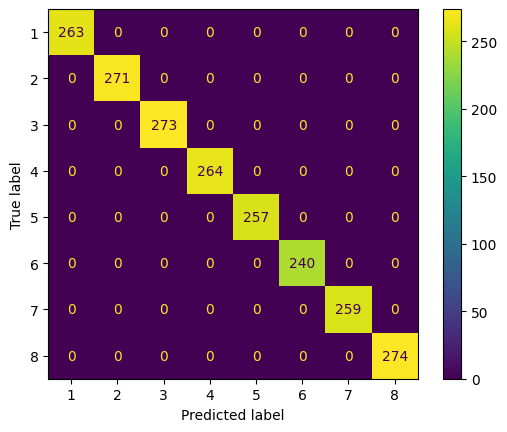

In [77]:
from sklearn.metrics import  ConfusionMatrixDisplay
print(ConfusionMatrixDisplay.from_predictions(y_test,y_predict))

In [78]:
from sklearn.metrics import precision_score

# For multiclass classification, you need to specify the 'average' parameter.
# 'weighted' accounts for class imbalance.
precision = precision_score(y_test, y_predict, average='weighted')
print(f"Precision (weighted): {precision:.4f}")

# 'macro' calculates metrics for each label, and finds their unweighted mean.
precision_macro = precision_score(y_test, y_predict, average='macro')
print(f"Precision (macro): {precision_macro:.4f}")

Precision (weighted): 1.0000
Precision (macro): 1.0000


In [79]:
from sklearn.metrics import recall_score

# Calculate recall using 'weighted' average
recall = recall_score(y_test, y_predict, average='weighted')
print(f"Recall (weighted): {recall:.4f}")

# Calculate recall using 'macro' average
recall_macro = recall_score(y_test, y_predict, average='macro')
print(f"Recall (macro): {recall_macro:.4f}")

Recall (weighted): 1.0000
Recall (macro): 1.0000


In [80]:
from sklearn.metrics import f1_score

# Calculate F1-score using 'weighted' average
f1 = f1_score(y_test, y_predict, average='weighted')
print(f"F1-Score (weighted): {f1:.4f}")

# Calculate F1-score using 'macro' average
f1_macro = f1_score(y_test, y_predict, average='macro')
print(f"F1-Score (macro): {f1_macro:.4f}")

F1-Score (weighted): 1.0000
F1-Score (macro): 1.0000


### Comprehensive Classification Report

To get a full breakdown of precision, recall, and F1-score for each class, along with overall averages, you can use `classification_report`:

In [81]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_predict))

              precision    recall  f1-score   support

           1       1.00      1.00      1.00       263
           2       1.00      1.00      1.00       271
           3       1.00      1.00      1.00       273
           4       1.00      1.00      1.00       264
           5       1.00      1.00      1.00       257
           6       1.00      1.00      1.00       240
           7       1.00      1.00      1.00       259
           8       1.00      1.00      1.00       274

    accuracy                           1.00      2101
   macro avg       1.00      1.00      1.00      2101
weighted avg       1.00      1.00      1.00      2101



In [106]:
user_inp="Spring Boot,PHP,Laravel,ASP.NET Core,REST API"
user_inp='hi there is a cat on the table'
inp_list=user_inp.split(',')
len_of_sp=len(inp_list)

sample=[user_inp]
sample=tfidf.transform(sample)
prediction=rnd.predict(sample)
print(inp_list)
prediction


['hi there is a cat on the table']


array([1])

In [108]:
designation_skills = {
    1: [
        "Front End Developer",
        ["HTML5","CSS3","JavaScript","TypeScript","React.js","Angular","Vue.js","Bootstrap","Tailwind CSS","jQuery","Redux","Responsive Design","Webpack","REST API","Git","Figma"]
    ],
    2: [
        "Backend Developer",
        ["Python","Java","C#","Node.js","Express.js","Django","Flask","Spring Boot","PHP","Laravel","ASP.NET Core","REST API","GraphQL","MySQL","PostgreSQL","MongoDB","Redis","Docker","Git","Linux"]
    ],
    3: [
        "Data Analyst",
        ["Python","SQL","Excel","Power BI","Tableau","Pandas","NumPy","Matplotlib","Seaborn","Statistics","Data Cleaning","Data Visualization","Business Intelligence","ETL","Google Sheets","R Programming"]
    ],
    4: [
        "Cloud Engineer",
        ["AWS","Azure","Google Cloud Platform","Docker","Kubernetes","Terraform","Linux","Bash","CI/CD","Jenkins","GitHub Actions","Ansible","CloudFormation","Networking","Python","Monitoring"]
    ],
    5: [
        "ML Engineer",
        ["Python","TensorFlow","PyTorch","Scikit-learn","Pandas","NumPy","OpenCV","NLP","Deep Learning","Machine Learning","Feature Engineering","Model Deployment","Docker","FastAPI","MLflow","SQL"]
    ],
    6: [
        "HR Manager",
        ["Recruitment","Talent Acquisition","Employee Relations","Payroll","HRMS","Performance Management","Onboarding","Training & Development","Compliance","Labor Laws","Communication","Conflict Resolution","MS Excel","MS Office","Leadership","Interviewing"]
    ],
    7: [
        "Designer",
        ["Adobe Photoshop","Adobe Illustrator","Figma","Adobe XD","Sketch","Canva","UI Design","UX Design","Wireframing","Prototyping","Typography","Color Theory","Responsive Design","Branding","After Effects","InDesign"]
    ],
    8: [
        "Digital Marketing",
        ["SEO","SEM","Google Ads","Meta Ads","Content Marketing","Email Marketing","Social Media Marketing","Google Analytics","Keyword Research","WordPress","Canva","Copywriting","Marketing Automation","Lead Generation","CRM","Campaign Management"]
    ]
}


designation = designation_skills[prediction[0]][0]
required_skills = set(designation_skills[prediction[0]][1])
user_skills = set(inp_list)

missing_skills = sorted(required_skills - user_skills)

threshold = len(required_skills) / 2.5

print("Predicted Designation :", designation)
print("User Skills           :", sorted(user_skills))
print("Required Skills       :", sorted(required_skills))
print("Missing Skills        :", missing_skills)
print("Threshold             :", threshold)

if len(user_skills) >= threshold:
    print(f"\nYour predicted designation is: {designation}")
elif len(missing_skills)==len(required_skills):
    print('you are not eligible for any of our desination')
else:
    print(f"\nYou need to learn at least {len(missing_skills)} more skills for {designation}.")


Predicted Designation : Front End Developer
User Skills           : ['hi there is a cat on the table']
Required Skills       : ['Angular', 'Bootstrap', 'CSS3', 'Figma', 'Git', 'HTML5', 'JavaScript', 'REST API', 'React.js', 'Redux', 'Responsive Design', 'Tailwind CSS', 'TypeScript', 'Vue.js', 'Webpack', 'jQuery']
Missing Skills        : ['Angular', 'Bootstrap', 'CSS3', 'Figma', 'Git', 'HTML5', 'JavaScript', 'REST API', 'React.js', 'Redux', 'Responsive Design', 'Tailwind CSS', 'TypeScript', 'Vue.js', 'Webpack', 'jQuery']
Threshold             : 6.4
you are not eligible for any of our desination
